In [4]:
from sklearn.datasets import fetch_openml 
from sklearn.datasets import get_data_home
import os
from sklearn.datasets import fetch_openml
# 在导入或执行下载前设置环境变量
os.environ['SCIKIT_LEARN_DATA'] = r'W:\UWA\2026S1\HandsonML\Chapter_3\dataset'

In [5]:
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [6]:
X,y = mnist["data"],mnist["target"]
X.shape

(70000, 784)

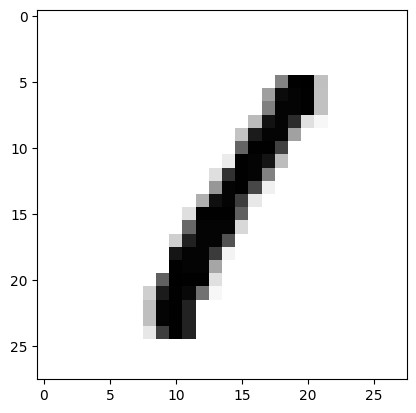

5


In [7]:
import matplotlib as mpl 
import matplotlib.pyplot as plt 
import numpy as np
some_digit = X.iloc[3].values
some_digit_image = some_digit.reshape(28, 28) 
plt.imshow(some_digit_image, cmap="binary") 
# plt.axis("off") 
plt.show() 
y = y.astype(np.uint8) 
print(y[0])

In [8]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [19]:
y_train_5 = (y_train == 5)  # True for all 5s, False for all other digits 
y_test_5 = (y_test == 5)

from sklearn.linear_model import SGDClassifier 
sgd_clf = SGDClassifier(random_state=42) 
sgd_clf.fit(X_train, y_train_5) 

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [20]:
some_digit = X.iloc[0].values
sgd_clf.predict([some_digit]) 

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# 关键点：必须同时设置 random_state 和 shuffle=True
skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    
    # 使用 .iloc 进行行位置索引
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(f"准确率: {n_correct / len(y_pred):.4f}")

准确率: 0.9042
准确率: 0.9477
准确率: 0.9678


In [22]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [23]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self,X,y=None):
        return self
    def predict(self,X):
        return np.zeros((len(X),1),dtype = bool)

In [24]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5,cv = 3,scoring = "accuracy")

array([0.91125, 0.90855, 0.90915])

from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf ,X_train,y_train_5,cv = 3)

In [25]:
from sklearn.model_selection import cross_val_predict 
y_train_pred = cross_val_predict(sgd_clf ,X_train,y_train_5,cv = 3)

In [26]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [27]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5,y_train_pred)


0.8370879772350012

In [28]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [29]:
from sklearn.metrics import f1_score  

# 确保变量名是 y_train_5 而不是 y_train-5
score = f1_score(y_train_5, y_train_pred)
print(f"F1 分数是: {score:.4f}")

F1 分数是: 0.7325


In [30]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([2164.22030239])

In [31]:
threshold = 0
y_some_digit_pred = (y_scores > threshold) 
y_some_digit_pred 

array([ True])

In [32]:
threshold = 8000
y_some_digit_pred = (y_scores > threshold) 
y_some_digit_pred

array([False])

In [33]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, 
                             method="decision_function") 


In [34]:
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

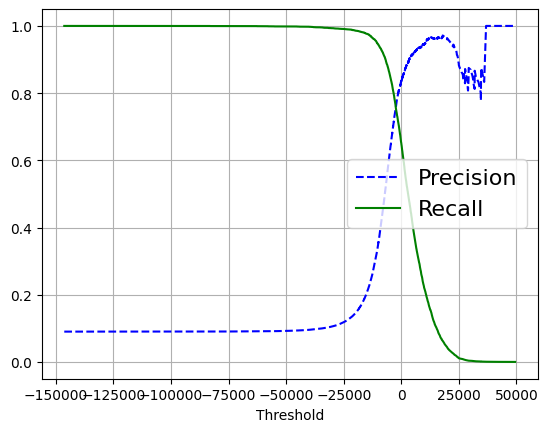

In [35]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds): 
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision") 
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall") 
    [...] # highlight the threshold and add the legend, axis label, and grid 
    plt.legend(loc="center right", fontsize=16) # 设置位置和字号
    plt.grid(True)                              # 开启网格线
    plt.xlabel("Threshold")
plot_precision_recall_vs_threshold(precisions, recalls, thresholds) 
plt.show() 

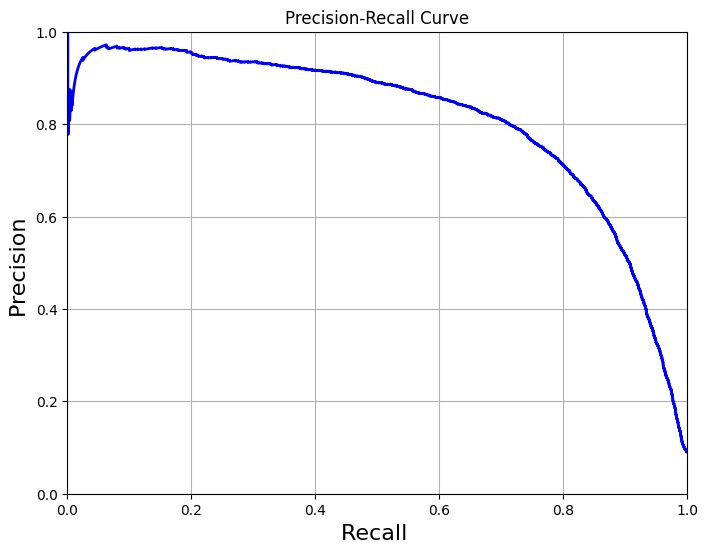

In [36]:
def plot_precision_vs_recall(precisions, recalls):
    # 绘图：横轴是召回率，纵轴是精度
    plt.plot(recalls, precisions, "b-", linewidth=2)
    
    # 设置坐标轴标签
    plt.xlabel("Recall ", fontsize=16)
    plt.ylabel("Precision ", fontsize=16)
    
    # 设置坐标轴范围和网格
    plt.axis([0, 1, 0, 1])
    plt.grid(True)
    
    # 可以在图上标注出你关心的那个点（比如 90% 精度对应的位置）
    # plt.plot([0.43, 0.43], [0, 0.9], "r:") # 示例：用红虚线标出特定点
    # plt.plot([0, 0.43], [0.9, 0.9], "r:")
    # plt.plot([0.43], [0.9], "ro")

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.title("Precision-Recall Curve")
plt.show()

In [37]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)] 
threshold_90_precision

np.float64(3370.0194991439557)

In [38]:
y_train_pred_90 =  (y_scores >= threshold_90_precision) 
y_train_pred_90
precision_score(y_train_5, y_train_pred_90) 
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

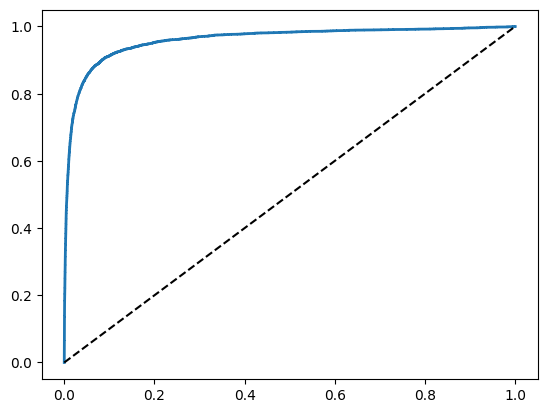

0.9604938554008616

In [39]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds = roc_curve(y_train_5, y_scores)

def plot_roc_curve(fpr, tpr, label=None): 
    plt.plot(fpr, tpr, linewidth=2, label=label) 
    plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal 
    [...] # Add axis labels and grid 
plot_roc_curve(fpr, tpr) 
plt.show() 

from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

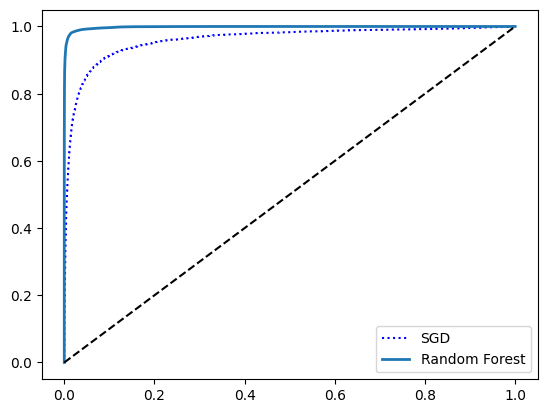

0.9983436731328145

In [40]:
from sklearn.ensemble import RandomForestClassifier 
forest_clf = RandomForestClassifier(random_state=42) 
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, 
                                    method="predict_proba") 
y_scores_forest = y_probas_forest[:, 1]   # score = proba of positive class 
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest) 

plt.plot(fpr, tpr, "b:", label="SGD") 
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest") 
plt.legend(loc="lower right") 
plt.show()

roc_auc_score(y_train_5, y_scores_forest) 

In [41]:
from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(X_train, y_train) 
svm_clf.predict([some_digit]) 

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([5], dtype=uint8)

In [42]:
some_digit_scores = svm_clf.decision_function([some_digit]) 
some_digit_scores

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [43]:
np.argmax(some_digit_scores)

np.int64(5)

In [45]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [46]:
svm_clf.classes_[5] 

np.uint8(5)

In [48]:
from sklearn.multiclass import  OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC()) 
ovr_clf.fit(X_train, y_train) 
ovr_clf.predict([some_digit]) 

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not h

array([5], dtype=uint8)

In [49]:
 len(ovr_clf.estimators_) 

10

In [51]:
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit]) 

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([3], dtype=uint8)

In [54]:
sgd_clf.decision_function([some_digit]) 
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([0.87745, 0.85835, 0.8698 ])

In [57]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy") 

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

In [58]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred) 
conf_mx 

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5573,    0,   23,    5,    8,   44,   36,    6,  227,    1],
       [   0, 6398,   37,   24,    4,   43,    4,    7,  214,   11],
       [  29,   25, 5220,   91,   73,   25,   68,   36,  380,   11],
       [  22,   17,  117, 5224,    2,  204,   27,   40,  405,   73],
       [  12,   14,   40,    9, 5181,   12,   34,   25,  351,  164],
       [  26,   15,   29,  165,   53, 4445,   74,   14,  541,   59],
       [  30,   15,   43,    3,   43,   96, 5551,    3,  133,    1],
       [  20,    9,   51,   29,   49,   12,    3, 5680,  200,  212],
       [  18,   64,   47,   89,    3,  124,   25,   10, 5426,   45],
       [  23,   18,   30,   65,  117,   37,    1,  179,  387, 5092]])

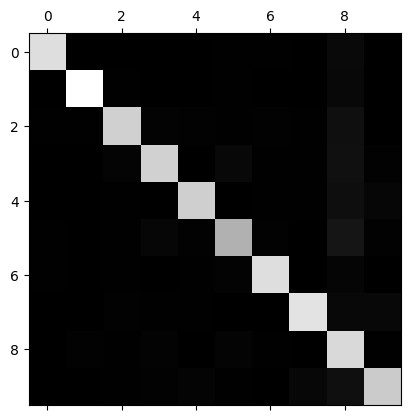

In [59]:
plt.matshow(conf_mx, cmap=plt.cm.gray) 
plt.show()

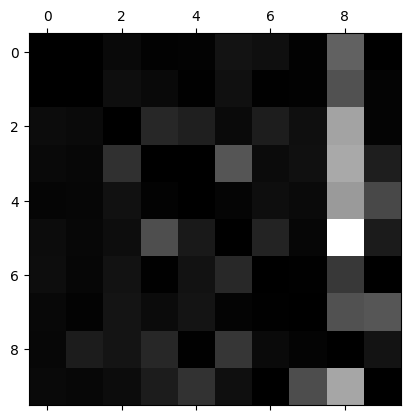

In [61]:
row_sums = conf_mx.sum(axis=1, keepdims=True) 
norm_conf_mx = conf_mx / row_sums 
np.fill_diagonal(norm_conf_mx, 0) 
plt.matshow(norm_conf_mx, cmap=plt.cm.gray) 
plt.show() 

In [9]:
from sklearn.neighbors import KNeighborsClassifier 
y_train_large = (y_train >= 7) 
y_train_odd = (y_train % 2 == 1) 
y_multilabel = np.c_[y_train_large, y_train_odd] 
knn_clf = KNeighborsClassifier() 
knn_clf.fit(X_train, y_multilabel) 

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [11]:
knn_clf.predict([some_digit])

C:\Users\Junhan Xu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([[False,  True]])

In [12]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

NameError: name 'cross_val_predict' is not defined